In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

#Data
df = pd.read_csv("../../data/geocoded_data/new_scores.csv")

# Keep only valid coordinates
df = df[df["ok"] == True]
df = df.dropna(subset=["lat", "lng"])

print(df.shape)
df.head()


C:\Users\shrey\AppData\Local\Temp\ipykernel_3620\2853862544.py:6: DtypeWarning: Columns (3,4,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/geocoded_data/new_scores.csv")


(442395, 32)


,Opened,Description,Address,Zip Code,Closed Date 1,Closed Date 2,Status,Number,closed,resolution_time_hours,...,domain_weight,issue_weight,severity_score,expected_resolution,resolution_factor,q10,q25,q75,q90,resolution_score
0,2021-03-02 13:30:00,Information on How to Request an Account Adjus...,"4501 Dudley LN NW, Atlanta, 30327",30327,2021-09-13 11:28:56,NaN,Resolved,CS0063095,2021-09-13 11:28:56,4677.982222,...,2,2,4,10.614444,440.718518,0.905370,0.911311,5.768855,88.451246,1
1,2021-03-03 13:30:00,Information on How to Dispute Your Water and S...,"238 peachtree cir, ATLANTA, 30309",30309,2021-07-15 12:54:21,NaN,Resolved,CS0060088,2021-07-15 12:54:21,3215.405833,...,5,1,5,9.782083,328.703582,0.979029,0.984112,2.391575,32.619642,1
2,2021-03-03 13:30:00,Information on How to Dispute Your Water and S...,"3434 Habersham Rd NW, Atlanta, 30305",30305,2022-05-26 09:54:34,NaN,Resolved,CS0026984,2022-05-26 09:54:34,10772.409444,...,5,1,5,9.782083,1101.238773,0.979029,0.984112,2.391575,32.619642,1
3,2021-03-09 13:30:00,Street Light Bulb Replacement or Street Light ...,"1160 Veltrie Circle, ATLANTA, 30311",30311,2021-04-14 15:24:37,NaN,Resolved,CS0001758,2021-04-14 15:24:37,865.910278,...,4,3,12,51.054722,16.960435,0.226881,0.507299,13.972149,336.648912,2
4,2021-03-11 13:30:00,Right of Way Maintenance Visibility/Overgrowth...,"2855 elliott cir , ATLANTA, 30305",30305,NaN,2025-06-03 17:47:00,Resolved,CS0056768,2025-06-03 17:47:00,37084.283333,...,4,1,4,93.250000,397.686685,0.104471,0.283426,9.242181,63.591008,1


In [2]:
import os
import requests
import zipfile


# create geometry column
geometry = [Point(xy) for xy in zip(df["lng"], df["lat"])]

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326" 
)

url = "https://www2.census.gov/geo/tiger/TIGER2020/TABBLOCK20/tl_2020_13_tabblock20.zip"
zip_path = "tl_2020_13_tabblock20.zip"
out_dir = "tl_2020_13_tabblock20"

# download
if not os.path.exists(zip_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

# unzip
if not os.path.exists(out_dir):
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

# read shapefile
shp_path = os.path.join(out_dir, "tl_2020_13_tabblock20.shp")
blocks_ga = gpd.read_file(shp_path)

print(blocks_ga.columns)


url_place = "https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_13_place.zip"
zip_place = "tl_2020_13_place.zip"
out_place = "tl_2020_13_place"

# 1) Download
if not os.path.exists(zip_place):
    print("Downloading PLACE shapefile...")
    r = requests.get(url_place, stream=True)
    r.raise_for_status()
    with open(zip_place, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

# 2) Unzip
if not os.path.exists(out_place):
    os.makedirs(out_place, exist_ok=True)
    with zipfile.ZipFile(zip_place, "r") as z:
        z.extractall(out_place)

print("Download complete.")




Index(['STATEFP20', 'COUNTYFP20', 'TRACTCE20', 'BLOCKCE20', 'GEOID20',
       'GEOIDFQ20', 'NAME20', 'MTFCC20', 'UR20', 'UACE20', 'FUNCSTAT20',
       'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'HOUSING20', 'POP20',
       'geometry'],
      dtype='object')
Download complete.


Total Atlanta blocks: 6571
Unmatched after filtering: 0


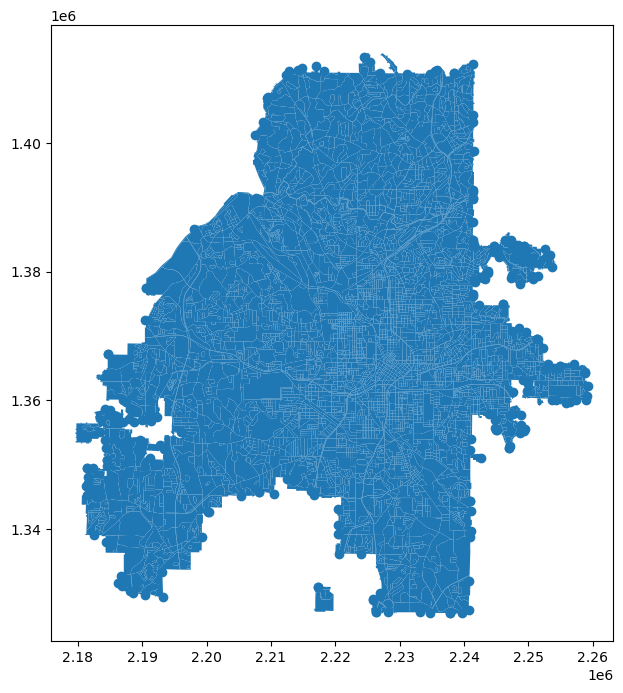

In [3]:
import geopandas as gpd
import os

# Load Atlanta boundary
place_path = os.path.join(out_place, "tl_2020_13_place.shp")
places = gpd.read_file(place_path)
atlanta_city = places[places["NAME"] == "Atlanta"].copy()

# Ensure same CRS
atlanta_city = atlanta_city.to_crs(gdf_points.crs)

# Filter only Atlanta points 
gdf_points_atl = gdf_points[
    gdf_points.within(atlanta_city.geometry.iloc[0])
].copy()

# Convert to projected CRS
gdf_points_atl = gdf_points_atl.to_crs("EPSG:2240")
blocks_ga = blocks_ga.to_crs("EPSG:2240")

# Clip blocks to Atlanta
atlanta_blocks = gpd.clip(blocks_ga, atlanta_city.to_crs("EPSG:2240"))

print("Total Atlanta blocks:", len(atlanta_blocks)) 
atlanta_blocks.plot(figsize=(8,8))


# Final spatial join
joined = gpd.sjoin(
    gdf_points_atl,
    atlanta_blocks,
    how="left",
    predicate="within"
)

# Check unmatched
print("Unmatched after filtering:", joined["GEOID20"].isna().sum())


In [4]:
gdf_points_atl.columns

Index(['Opened', 'Description', 'Address', 'Zip Code', 'Closed Date 1',
       'Closed Date 2', 'Status', 'Number', 'closed', 'resolution_time_hours',
       'has_closure_time', 'zip_clean', 'zip_int', 'address_norm', 'lat',
       'lng', 'ok', 'year', 'Short Description', 'Description_norm', 'domain',
       'issue_type', 'domain_weight', 'issue_weight', 'severity_score',
       'expected_resolution', 'resolution_factor', 'q10', 'q25', 'q75', 'q90',
       'resolution_score', 'geometry'],
      dtype='object')

**Burden Analysis**

In [5]:
block_counts = (
    joined.groupby("GEOID20")
    .size()
    .reset_index(name="complaint_count")
)

atlanta_blocks = atlanta_blocks.merge(
    block_counts,
    on="GEOID20",
    how="left"
)

atlanta_blocks["complaint_count"] = (
    atlanta_blocks["complaint_count"].fillna(0)
)

print("Total blocks:", len(atlanta_blocks))
print("Blocks with complaints:",
      (atlanta_blocks["complaint_count"] > 0).sum())



Total blocks: 6571
Blocks with complaints: 5414


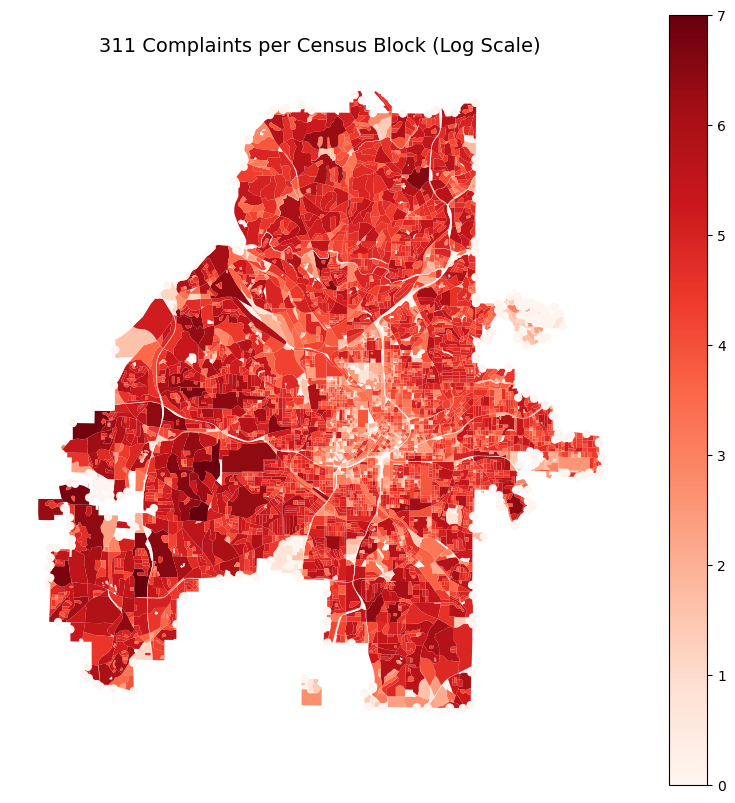

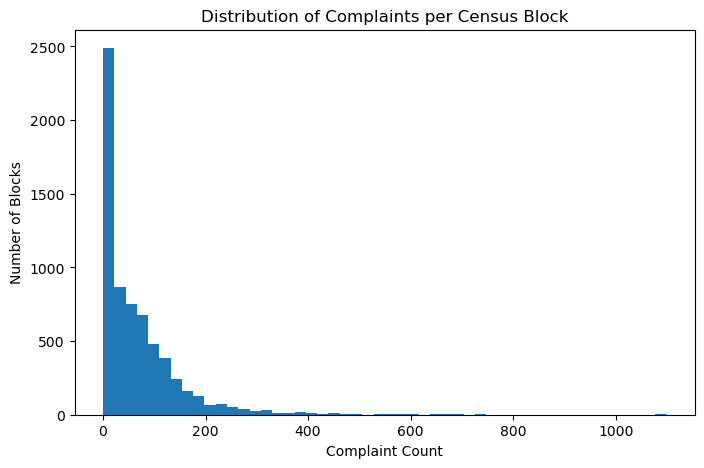

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# log transform
atlanta_blocks["log_count"] = np.log1p(atlanta_blocks["complaint_count"])

fig, ax = plt.subplots(figsize=(10,10))

atlanta_blocks.plot(
    column="log_count",
    cmap="Reds",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_title("311 Complaints per Census Block (Log Scale)", fontsize=14)
ax.axis("off")

plt.show()


plt.figure(figsize=(8,5))

plt.hist(
    atlanta_blocks["complaint_count"],
    bins=50
)

plt.title("Distribution of Complaints per Census Block")
plt.xlabel("Complaint Count")
plt.ylabel("Number of Blocks")

plt.show()


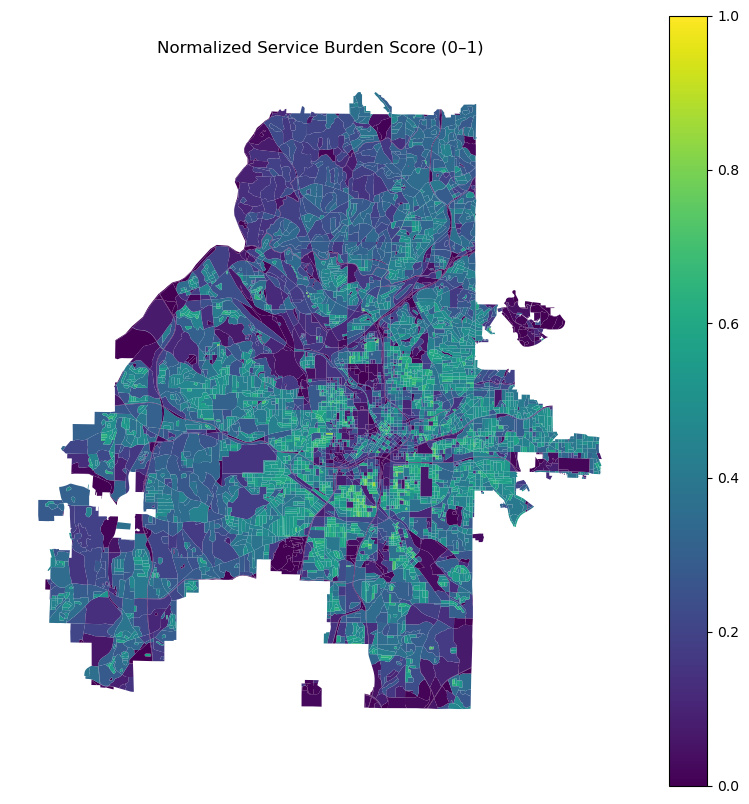

In [7]:
# Normalised based on area

atlanta_blocks["area_acres"] = atlanta_blocks.geometry.area / 43560
atlanta_blocks = atlanta_blocks[
    atlanta_blocks["area_acres"] > 0.01
].copy()


atlanta_blocks["service_burden_area"] = (
    atlanta_blocks["complaint_count"] /
    atlanta_blocks["area_acres"]
)

atlanta_blocks["log_burden"] = np.log1p(
    atlanta_blocks["service_burden_area"]
)

min_val = atlanta_blocks["log_burden"].min()
max_val = atlanta_blocks["log_burden"].max()

atlanta_blocks["burden_score"] = (
    (atlanta_blocks["log_burden"] - min_val) /
    (max_val - min_val)
)

atlanta_blocks["burden_score"].describe()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

atlanta_blocks.plot(
    column="burden_score",
    cmap="viridis",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_title("Normalized Service Burden Score (0–1)")
ax.axis("off")

plt.show()


In [8]:
#Deep copy of the base data - atlanta_blocks - used for 5 year analysis
atlanta_blocks_base = atlanta_blocks[[
    "GEOID20",
    "geometry",
    "area_acres",
    "POP20"
]].copy()


C:\Users\shrey\AppData\Local\Temp\ipykernel_3620\718596565.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


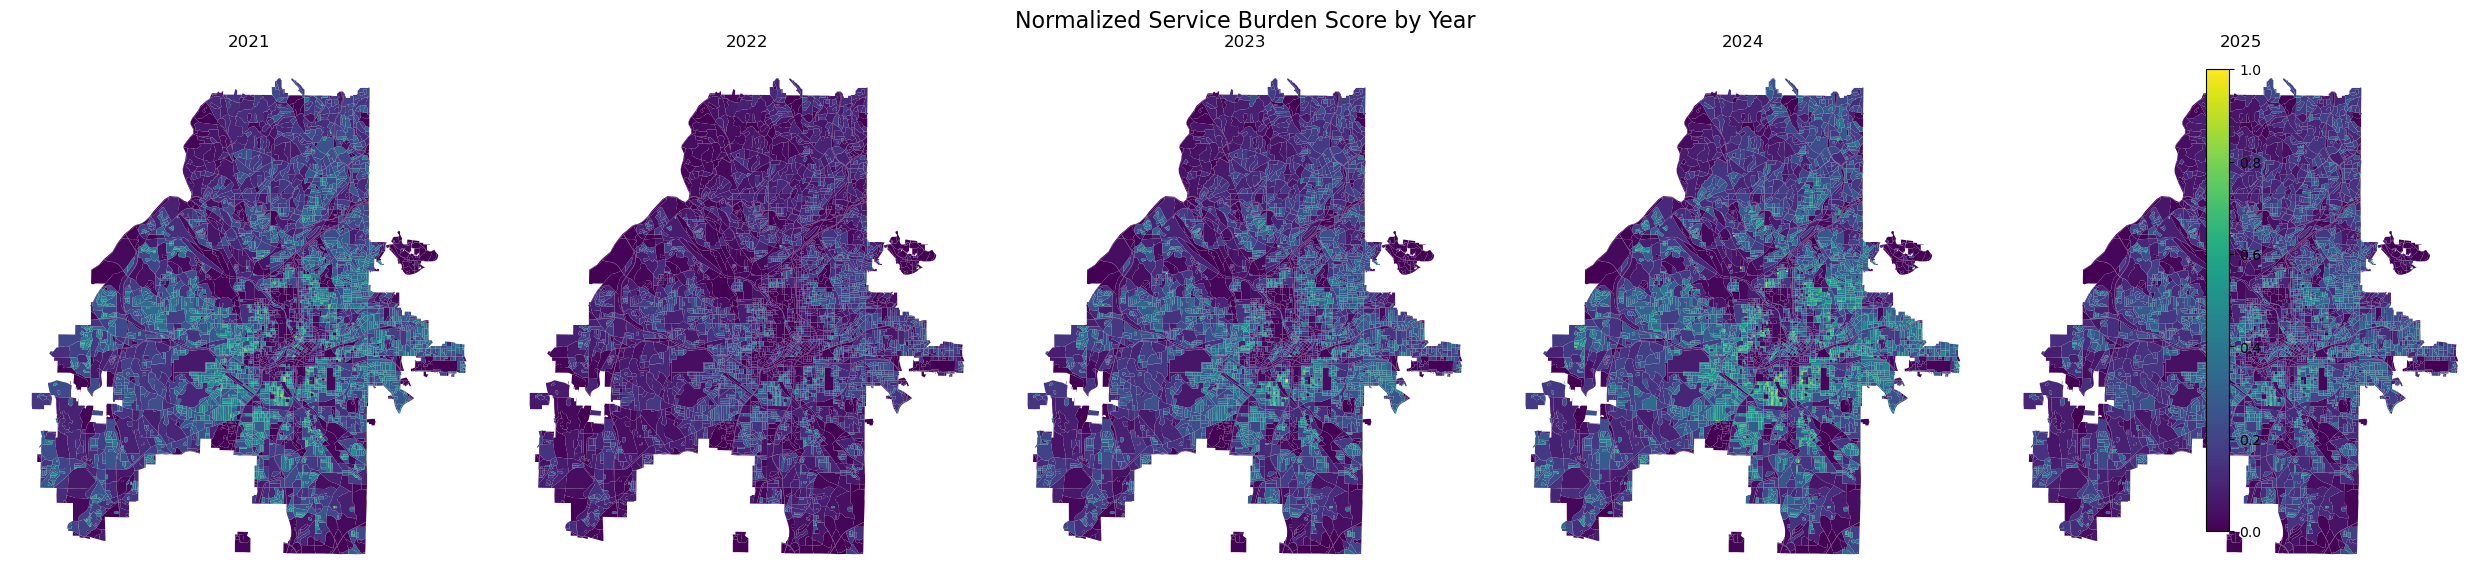

In [9]:
#Plotting 5 years trend

years = sorted(gdf_points_atl["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(
    1,                
    n_years,          
    figsize=(5*n_years, 6)
)

if n_years == 1:
    axes = [axes]

for i, yr in enumerate(years):
    
    yearly_points = gdf_points_atl[gdf_points_atl["year"] == yr]
    
    joined_year = gpd.sjoin(
        yearly_points,
        atlanta_blocks_base,
        how="left",
        predicate="within"
    )
    
    counts = (
        joined_year.groupby("GEOID20")
        .size()
        .reset_index(name="complaint_count")
    )
    
    blocks_year = atlanta_blocks_base.merge(
        counts,
        on="GEOID20",
        how="left"
    )
    
    blocks_year["complaint_count"] = (
        blocks_year["complaint_count"].fillna(0)
    )
    
    blocks_year["burden"] = (
        blocks_year["complaint_count"] /
        blocks_year["area_acres"]
    )
    
    blocks_year["log_burden"] = np.log1p(blocks_year["burden"])
    
    # Min–max scaling within year
    min_val = blocks_year["log_burden"].min()
    max_val = blocks_year["log_burden"].max()
    
    blocks_year["score"] = (
        (blocks_year["log_burden"] - min_val) /
        (max_val - min_val)
    )
    
    # Plot in subplot
    blocks_year.plot(
        column="score",
        cmap="viridis",
        linewidth=0,
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(str(yr))
    axes[i].axis("off")

sm = plt.cm.ScalarMappable(cmap="viridis")
sm.set_array([])

fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02)

plt.suptitle("Normalized Service Burden Score by Year", fontsize=16)
plt.tight_layout()
plt.show()


In [10]:
gdf_points_atl.head

<bound method NDFrame.head of                      Opened  \
0       2021-03-02 13:30:00   
1       2021-03-03 13:30:00   
2       2021-03-03 13:30:00   
3       2021-03-09 13:30:00   
4       2021-03-11 13:30:00   
...                     ...   
442390  2025-11-18 21:06:00   
442391  2025-11-18 21:07:00   
442392  2025-11-18 21:29:00   
442393  2025-11-18 21:44:00   
442394  2025-11-18 21:49:00   

                                              Description  \
0       Information on How to Request an Account Adjus...   
1       Information on How to Dispute Your Water and S...   
2       Information on How to Dispute Your Water and S...   
3       Street Light Bulb Replacement or Street Light ...   
4       Right of Way Maintenance Visibility/Overgrowth...   
...                                                   ...   
442390                               Street Light Repairs   
442391                              Missed Yard Trimmings   
442392                                Housing He

In [11]:

#Join with our block data
joined_all = gpd.sjoin(
    gdf_points_atl,
    atlanta_blocks[["GEOID20", "geometry"]],
    how="left",
    predicate="within"
)


**Calculating response score**

In [12]:
# #Assign scores right now
# gdf_points_atl["response_score"] = np.select(
#     [
#         gdf_points_atl["resolution_time_hours"] <= 72,
#         gdf_points_atl["resolution_time_hours"].between(72, 168),
#         gdf_points_atl["resolution_time_hours"] > 168
#     ],
#     [10, 5, 1],
#     default=np.nan
# )
# gdf_points_atl["response_score"].describe()


# #Join with our block data
# joined_all = gpd.sjoin(
#     gdf_points_atl,
#     atlanta_blocks[["GEOID20", "geometry"]],
#     how="left",
#     predicate="within"
# )


# #Compute mean response per block
# block_response = (
#     joined_all.groupby("GEOID20")["response_score"]
#     .mean()
#     .reset_index(name="mean_response_score")
# )

# #Merge into 5 year dataset
# atlanta_blocks = atlanta_blocks.merge(
#     block_response,
#     on="GEOID20",
#     how="left"
# )

# #Response score normalization
# min_resp = atlanta_blocks["mean_response_score"].min(skipna=True)
# max_resp = atlanta_blocks["mean_response_score"].max(skipna=True)

# atlanta_blocks["response_score_norm"] = (
#     (atlanta_blocks["mean_response_score"] - min_resp) /
#     (max_resp - min_resp)
# )

# atlanta_blocks["mean_response_score"].describe()
# atlanta_blocks["response_score_norm"].describe()

# fig, ax = plt.subplots(figsize=(8,8))

# atlanta_blocks.plot(
#     column="mean_response_score",
#     cmap="RdYlGn",
#     linewidth=0,
#     legend=True,
#     ax=ax
# )

# ax.set_title("Mean Response Score (10 - good resolution, 1 - worse resolution)")
# ax.axis("off")

# plt.show()


In [13]:
# # Yearly trend

# years = sorted(gdf_points_atl["year"].unique())
# n_years = len(years)

# fig, axes = plt.subplots(1, n_years, figsize=(5*n_years, 6))

# if n_years == 1:
#     axes = [axes]

# for i, yr in enumerate(years):
    
#     # Filter year
#     yearly_points = gdf_points_atl[gdf_points_atl["year"] == yr]
    
#     # Spatial join
#     joined_year = gpd.sjoin(
#         yearly_points,
#         atlanta_blocks_base,
#         how="left",
#         predicate="within"
#     )
    
#     # Mean response score per block
#     block_response = (
#         joined_year.groupby("GEOID20")["response_score"]
#         .mean()
#         .reset_index(name="mean_response_score")
#     )
    
#     blocks_year = atlanta_blocks_base.merge(
#         block_response,
#         on="GEOID20",
#         how="left"
#     )
    
#     blocks_year = blocks_year.dropna(subset=["mean_response_score"])
    
#     min_resp = blocks_year["mean_response_score"].min()
#     max_resp = blocks_year["mean_response_score"].max()
    
#     blocks_year["response_score_norm"] = (
#         (blocks_year["mean_response_score"] - min_resp) /
#         (max_resp - min_resp)
#     )
    
#     # Plot
#     blocks_year.plot(
#         column="response_score_norm",
#         cmap="RdYlGn",
#         linewidth=0,
#         legend=False,
#         ax=axes[i]
#     )
    
#     axes[i].set_title(str(yr))
#     axes[i].axis("off")

# sm = plt.cm.ScalarMappable(cmap="RdYlGn")
# sm.set_array([])
# fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02)

# plt.suptitle("Response Quality Score by Year (0–1)", fontsize=16)
# plt.tight_layout()
# plt.show()


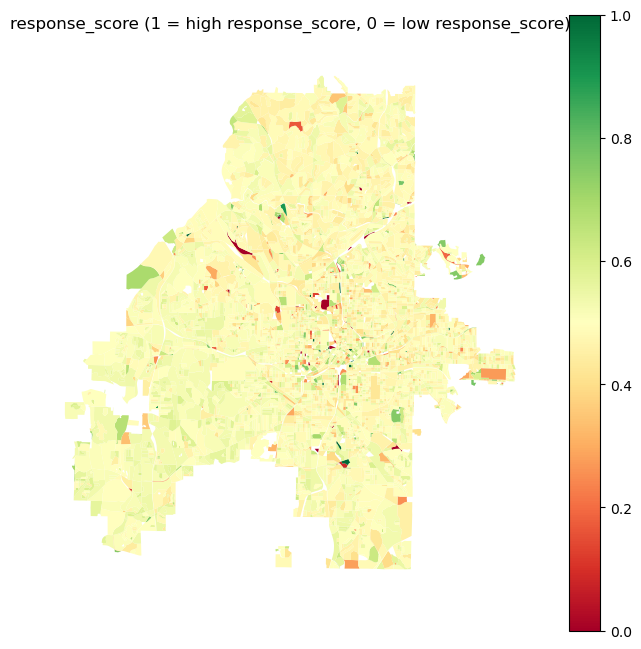

In [14]:
block_response_score = (
    joined_all.groupby("GEOID20")["resolution_score"]
    .mean()
    .reset_index(name="mean_response_score")
)

#Merge into 5 year dataset
atlanta_blocks = atlanta_blocks.merge(
    block_response_score,
    on="GEOID20",
    how="left"
)

#Severity score normalization
min_score = atlanta_blocks["mean_response_score"].min(skipna=True)
max_score = atlanta_blocks["mean_response_score"].max(skipna=True)

atlanta_blocks["response_score_norm"] = (
    (atlanta_blocks["mean_response_score"] - min_score) /
    (max_score - min_score)
)

fig, ax = plt.subplots(figsize=(8,8))

atlanta_blocks.plot(
    column="response_score_norm",
    cmap="RdYlGn",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_title("response_score (1 = high response_score, 0 = low response_score)")
ax.axis("off")

plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_3620\2421196737.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


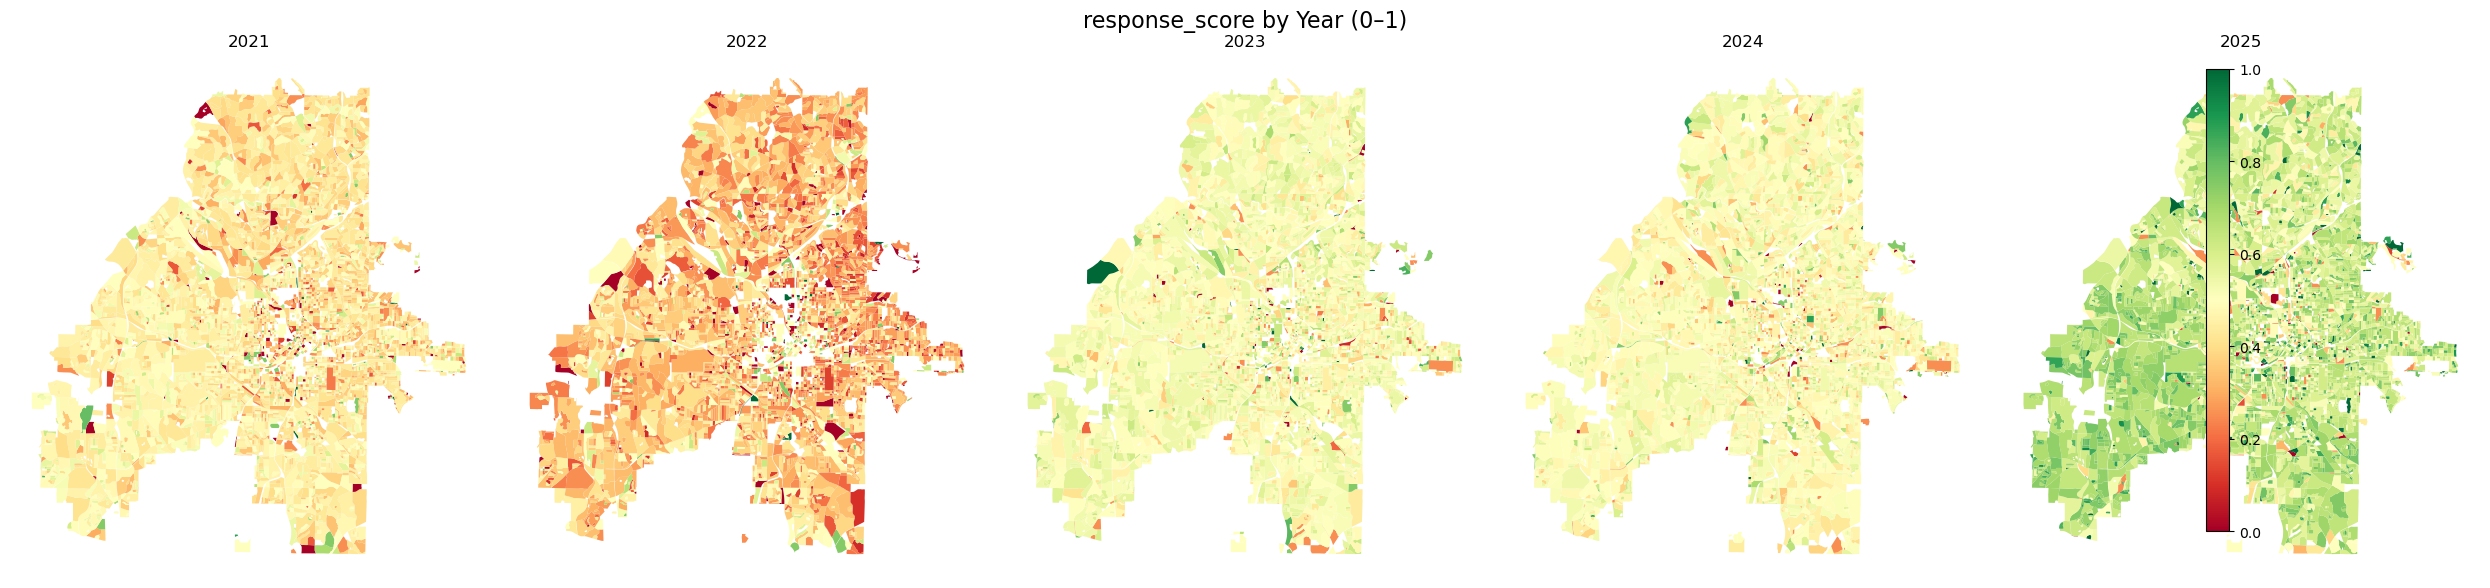

In [16]:
# Yearly trend for severity score

years = sorted(gdf_points_atl["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years, figsize=(5*n_years, 6))

if n_years == 1:
    axes = [axes]

for i, yr in enumerate(years):
    
    # Filter year
    yearly_points = gdf_points_atl[gdf_points_atl["year"] == yr]
    
    # Spatial join
    joined_year = gpd.sjoin(
        yearly_points,
        atlanta_blocks_base,
        how="left",
        predicate="within"
    )
    
    #  Mean severity score per block
    block_response_score = (
        joined_year.groupby("GEOID20")["resolution_score"]
        .mean()
        .reset_index(name="mean_response_score")
    )
    
    blocks_year = atlanta_blocks_base.merge(
        block_response_score,
        on="GEOID20",
        how="left"
    )
    
    # Keep only blocks with complaints
    blocks_year = blocks_year.dropna(subset=["mean_response_score"])
    
    # Normalize within year (observed scaling)
    min_response_score = blocks_year["mean_response_score"].min()
    max_response_score = blocks_year["mean_response_score"].max()
    
    blocks_year["response_score_norm"] = (
        (blocks_year["mean_response_score"] - min_response_score) /
        (max_response_score - min_response_score)
    )
    
    # Plot
    blocks_year.plot(
        column="response_score_norm",
        cmap="RdYlGn",
        linewidth=0,
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(str(yr))
    axes[i].axis("off")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="RdYlGn")
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02)

plt.suptitle("response_score by Year (0–1)", fontsize=16)
plt.tight_layout()
plt.show()

**Compute average severity score for a block**

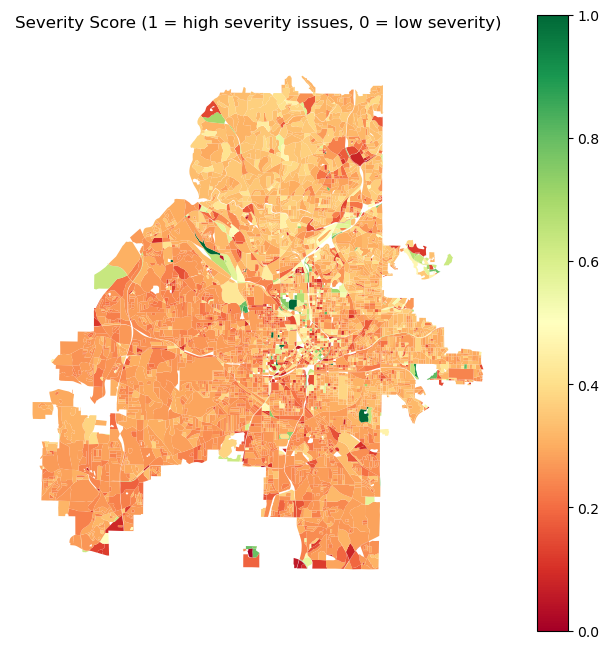

In [17]:
block_severity_score = (
    joined_all.groupby("GEOID20")["severity_score"]
    .mean()
    .reset_index(name="mean_severity_score")
)

#Merge into 5 year dataset
atlanta_blocks = atlanta_blocks.merge(
    block_severity_score,
    on="GEOID20",
    how="left"
)

#Severity score normalization
min_score = atlanta_blocks["mean_severity_score"].min(skipna=True)
max_score = atlanta_blocks["mean_severity_score"].max(skipna=True)

atlanta_blocks["severity_score_norm"] = (
    (atlanta_blocks["mean_severity_score"] - min_score) /
    (max_score - min_score)
)

fig, ax = plt.subplots(figsize=(8,8))

atlanta_blocks.plot(
    column="severity_score_norm",
    cmap="RdYlGn",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_title("Severity Score (1 = high severity issues, 0 = low severity)")
ax.axis("off")

plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_3620\953742266.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


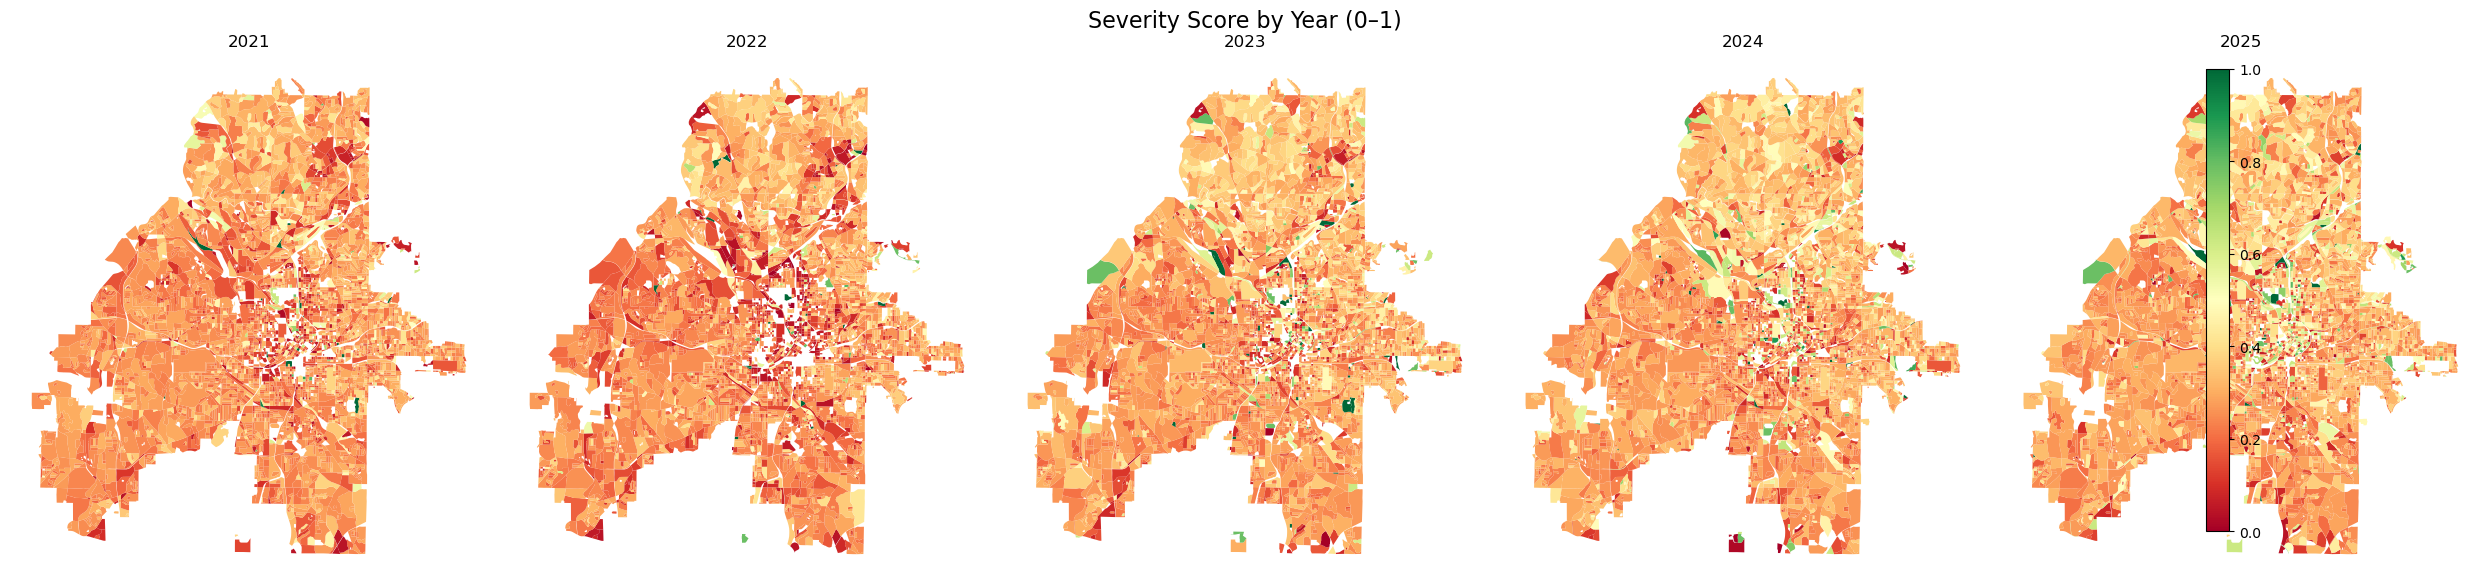

In [18]:
# Yearly trend for severity score

years = sorted(gdf_points_atl["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years, figsize=(5*n_years, 6))

if n_years == 1:
    axes = [axes]

for i, yr in enumerate(years):
    
    # Filter year
    yearly_points = gdf_points_atl[gdf_points_atl["year"] == yr]
    
    # Spatial join
    joined_year = gpd.sjoin(
        yearly_points,
        atlanta_blocks_base,
        how="left",
        predicate="within"
    )
    
    #  Mean severity score per block
    block_severity = (
        joined_year.groupby("GEOID20")["severity_score"]
        .mean()
        .reset_index(name="mean_severity_score")
    )
    
    blocks_year = atlanta_blocks_base.merge(
        block_severity,
        on="GEOID20",
        how="left"
    )
    
    # Keep only blocks with complaints
    blocks_year = blocks_year.dropna(subset=["mean_severity_score"])
    
    # Normalize within year (observed scaling)
    min_sev = blocks_year["mean_severity_score"].min()
    max_sev = blocks_year["mean_severity_score"].max()
    
    blocks_year["severity_score_norm"] = (
        (blocks_year["mean_severity_score"] - min_sev) /
        (max_sev - min_sev)
    )
    
    # Plot
    blocks_year.plot(
        column="severity_score_norm",
        cmap="RdYlGn",
        linewidth=0,
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(str(yr))
    axes[i].axis("off")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="RdYlGn")
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02)

plt.suptitle("Severity Score by Year (0–1)", fontsize=16)
plt.tight_layout()
plt.show()

**Composite score calculation!**

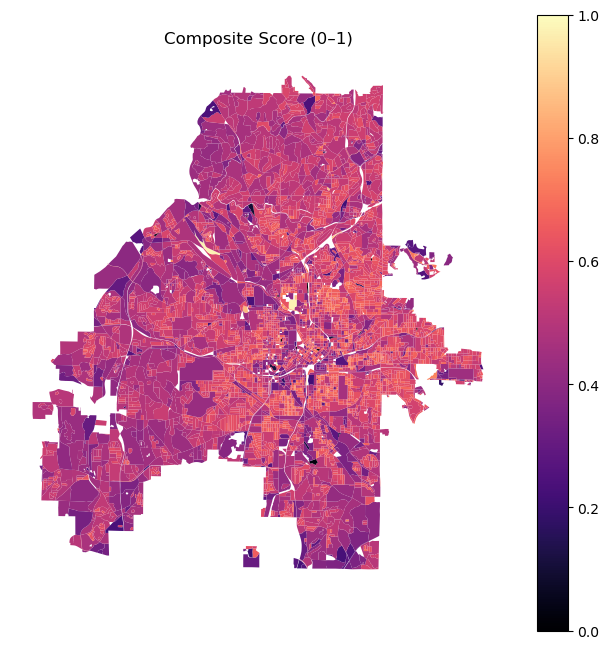

In [19]:
#### Composite score calculation

atlanta_blocks["response_badness"] = (
    1 - atlanta_blocks["response_score_norm"]
)

atlanta_blocks["composite_score_raw"] = (
    atlanta_blocks["burden_score"] +
    atlanta_blocks["response_badness"] + atlanta_blocks["severity_score_norm"]
)

min_c = atlanta_blocks["composite_score_raw"].min()
max_c = atlanta_blocks["composite_score_raw"].max()

atlanta_blocks["composite_score"] = (
    (atlanta_blocks["composite_score_raw"] - min_c) /
    (max_c - min_c)
)

fig, ax = plt.subplots(figsize=(8,8))

atlanta_blocks.plot(
    column="composite_score",
    cmap="magma",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_title("Composite Score (0–1)")
ax.axis("off")

plt.show()




C:\Users\shrey\AppData\Local\Temp\ipykernel_3620\3716569013.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


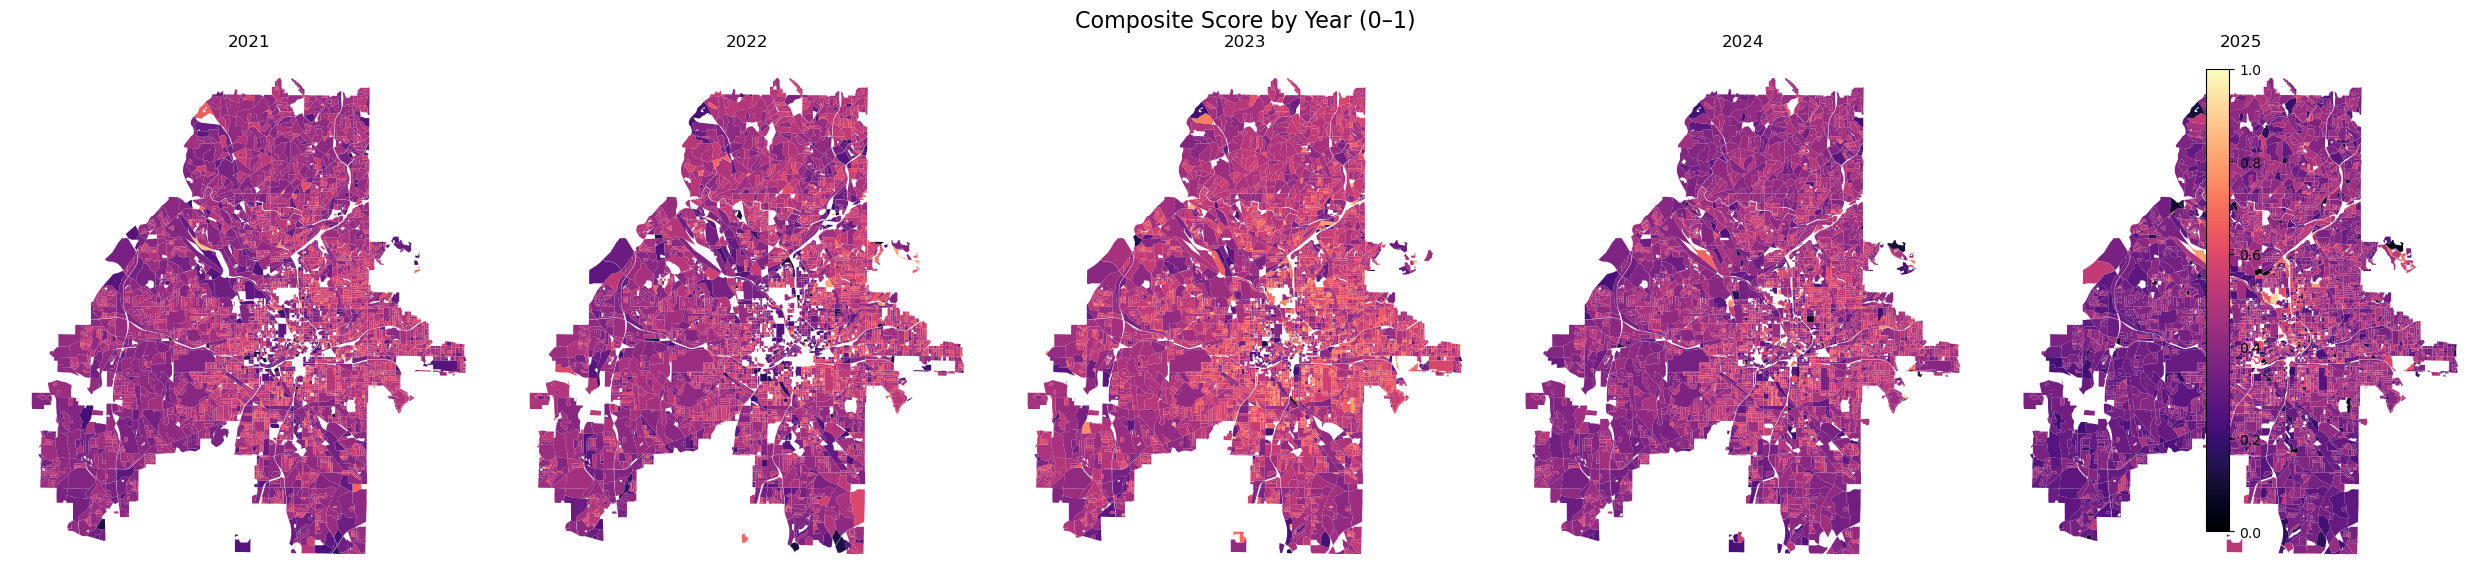

In [21]:
# Yearly composite score trend

years = sorted(gdf_points_atl["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years, figsize=(5*n_years, 6))

if n_years == 1:
    axes = [axes]

for i, yr in enumerate(years):
    
    #  Filter year
    yearly_points = gdf_points_atl[gdf_points_atl["year"] == yr]
    
    #  Spatial join
    joined_year = gpd.sjoin(
        yearly_points,
        atlanta_blocks_base,
        how="left",
        predicate="within"
    )
    
    # -------------------------------
    #  BURDEN 
    # -------------------------------
    counts = (
        joined_year.groupby("GEOID20")
        .size()
        .reset_index(name="complaint_count")
    )
    
    blocks_year = atlanta_blocks_base.merge(
        counts,
        on="GEOID20",
        how="left"
    )
    
    blocks_year["complaint_count"] = blocks_year["complaint_count"].fillna(0)
    
    blocks_year["burden"] = (
        blocks_year["complaint_count"] /
        blocks_year["area_acres"]
    )
    
    blocks_year["log_burden"] = np.log1p(blocks_year["burden"])
    
    # Normalize burden
    min_b = blocks_year["log_burden"].min()
    max_b = blocks_year["log_burden"].max()
    
    blocks_year["burden_score"] = (
        (blocks_year["log_burden"] - min_b) /
        (max_b - min_b)
    )
    
    # -------------------------------
    #  RESPONSE + SEVERITY
    # -------------------------------
    block_scores = joined_year.groupby("GEOID20").agg(
        mean_response_score=("resolution_score", "mean"),
        mean_severity_score=("severity_score", "mean")
    ).reset_index()
    
    blocks_year = blocks_year.merge(
        block_scores,
        on="GEOID20",
        how="left"
    )
    
    blocks_year = blocks_year.dropna(
        subset=["mean_response_score", "mean_severity_score"]
    )
    
    # Normalize response
    min_r = blocks_year["mean_response_score"].min()
    max_r = blocks_year["mean_response_score"].max()
    
    blocks_year["response_score_norm"] = (
        (blocks_year["mean_response_score"] - min_r) /
        (max_r - min_r)
    )
    
    # Convert to badness
    blocks_year["response_badness"] = 1 - blocks_year["response_score_norm"]
    
    # Normalize severity
    min_s = blocks_year["mean_severity_score"].min()
    max_s = blocks_year["mean_severity_score"].max()
    
    blocks_year["severity_score_norm"] = (
        (blocks_year["mean_severity_score"] - min_s) /
        (max_s - min_s)
    )
    
    # -------------------------------
    #  COMPOSITE SCORE
    # -------------------------------
    blocks_year["composite_raw"] = (
        blocks_year["burden_score"] +
        blocks_year["response_badness"] +
        blocks_year["severity_score_norm"]
    )
    
    min_c = blocks_year["composite_raw"].min()
    max_c = blocks_year["composite_raw"].max()
    
    blocks_year["composite_score"] = (
        (blocks_year["composite_raw"] - min_c) /
        (max_c - min_c)
    )
    
    # -------------------------------
    # PLOT
    # -------------------------------
    blocks_year.plot(
        column="composite_score",
        cmap="magma",
        linewidth=0,
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(str(yr))
    axes[i].axis("off")

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="magma")
sm.set_array([])

fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02)

plt.suptitle("Composite Score by Year (0–1)", fontsize=16)
plt.tight_layout()
plt.show()

**Good and bad performing blocks**

In [22]:
top_threshold = atlanta_blocks["composite_score"].quantile(0.90)
bottom_threshold = atlanta_blocks["composite_score"].quantile(0.10)

worst_blocks = atlanta_blocks[
    atlanta_blocks["composite_score"] >= top_threshold
]

best_blocks = atlanta_blocks[
    atlanta_blocks["composite_score"] <= bottom_threshold
]

print("Worst blocks:", len(worst_blocks))
print("Best blocks:", len(best_blocks))


Worst blocks: 542
Best blocks: 542


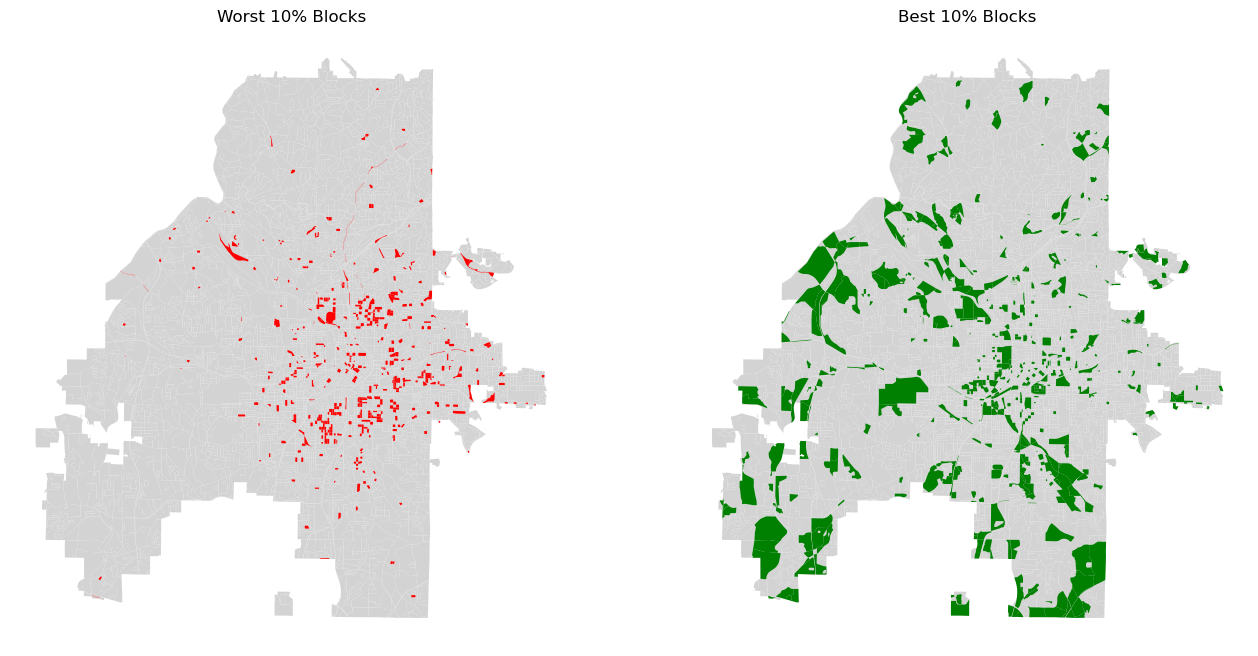

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))

# Worst
atlanta_blocks.plot(color="lightgrey", linewidth=0, ax=axes[0])
worst_blocks.plot(color="red", linewidth=0, ax=axes[0])
axes[0].set_title("Worst 10% Blocks")
axes[0].axis("off")

# Best
atlanta_blocks.plot(color="lightgrey", linewidth=0, ax=axes[1])
best_blocks.plot(color="green", linewidth=0, ax=axes[1])
axes[1].set_title("Best 10% Blocks")
axes[1].axis("off")

plt.show()


In [24]:
print("Worst Blocks Summary:")
print(worst_blocks[["burden_score", "response_score_norm", "severity_score_norm"]].mean())

print("\nBest Blocks Summary:")
print(best_blocks[["burden_score", "response_score_norm", "severity_score_norm"]].mean())


Worst Blocks Summary:
burden_score           0.566454
response_score_norm    0.447299
severity_score_norm    0.390006
dtype: float64

Best Blocks Summary:
burden_score           0.145910
response_score_norm    0.567318
severity_score_norm    0.210214
dtype: float64


In [25]:
# Corelation of scores

corr_value = (
    atlanta_blocks[["burden_score", "response_score_norm", "severity_score_norm"]]
    .dropna()
    .corr()
    
)

print("5-Year Correlation:", corr_value)

5-Year Correlation:                      burden_score  response_score_norm  severity_score_norm
burden_score             1.000000             0.025609            -0.154930
response_score_norm      0.025609             1.000000            -0.019526
severity_score_norm     -0.154930            -0.019526             1.000000
